In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/processed/the_grammy_awards.db")
grammys = pd.read_sql("SELECT * FROM grammys", conn)
conn.close()

grammys.head()

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,1
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,1
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,1
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,1
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,1


In [2]:
grammys.columns

Index(['year', 'title', 'published_at', 'updated_at', 'category', 'nominee',
       'artist', 'workers', 'img', 'winner'],
      dtype='str')

In [3]:
grammys.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          4810 non-null   int64
 1   title         4810 non-null   str  
 2   published_at  4810 non-null   str  
 3   updated_at    4810 non-null   str  
 4   category      4810 non-null   str  
 5   nominee       4804 non-null   str  
 6   artist        2970 non-null   str  
 7   workers       2620 non-null   str  
 8   img           3443 non-null   str  
 9   winner        4810 non-null   int64
dtypes: int64(2), str(8)
memory usage: 375.9 KB


In [6]:
grammys.describe()

,year,winner
count,4810.000000,4810.0
mean,1995.566944,1.0
std,17.149720,0.0
min,1958.000000,1.0
25%,1983.000000,1.0
50%,1998.000000,1.0
75%,2010.000000,1.0
max,2019.000000,1.0


In [4]:
grammys.isnull().sum()

year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64

In [5]:
grammys.duplicated().sum()

np.int64(0)

In [7]:
# años minimo y maximo
print(grammys["year"].min())
print(grammys["year"].max())

1958
2019


In [9]:
# revisar fechas
grammys["published_at"].head()
grammys["updated_at"].head()

0    2020-05-19T05:10:28-07:00
1    2020-05-19T05:10:28-07:00
2    2020-05-19T05:10:28-07:00
3    2020-05-19T05:10:28-07:00
4    2020-05-19T05:10:28-07:00
Name: updated_at, dtype: str

In [3]:
# variables clave
grammys[["year", "category", "nominee", "artist", "winner"]].head()

,year,category,nominee,artist,winner
0,2019,Record Of The Year,Bad Guy,Billie Eilish,1
1,2019,Record Of The Year,"Hey, Ma",Bon Iver,1
2,2019,Record Of The Year,7 rings,Ariana Grande,1
3,2019,Record Of The Year,Hard Place,H.E.R.,1
4,2019,Record Of The Year,Talk,Khalid,1


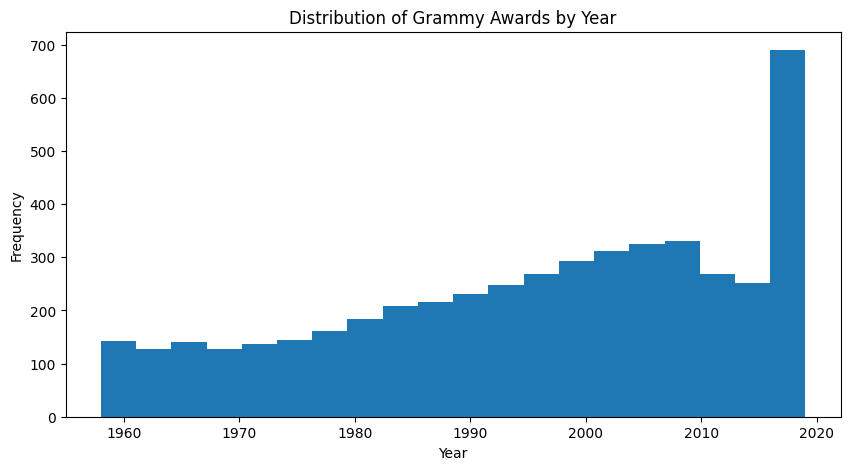

In [6]:
#Distribucion de años
plt.figure(figsize=(10,5))
plt.hist(grammys["year"].dropna(), bins=20)
plt.title("Distribution of Grammy Awards by Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

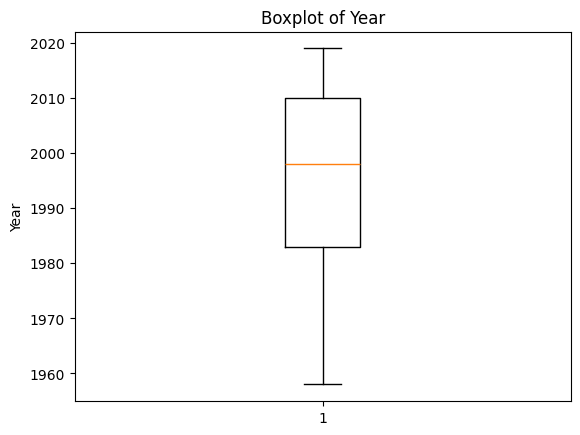

In [7]:
plt.figure()
plt.boxplot(grammys["year"].dropna())
plt.title("Boxplot of Year")
plt.ylabel("Year")
plt.show()

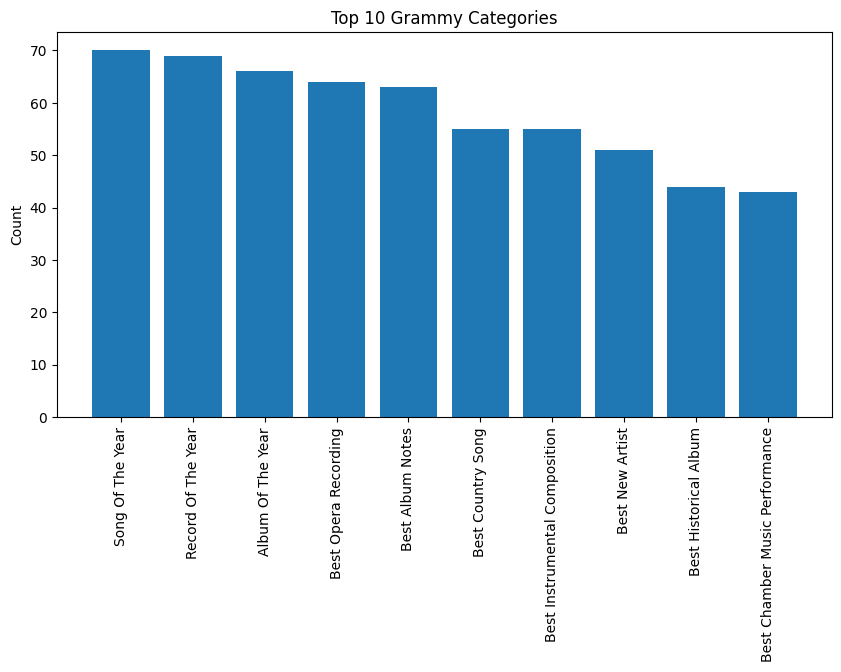

In [8]:
top_categories = grammys["category"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_categories.index, top_categories.values)
plt.title("Top 10 Grammy Categories")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

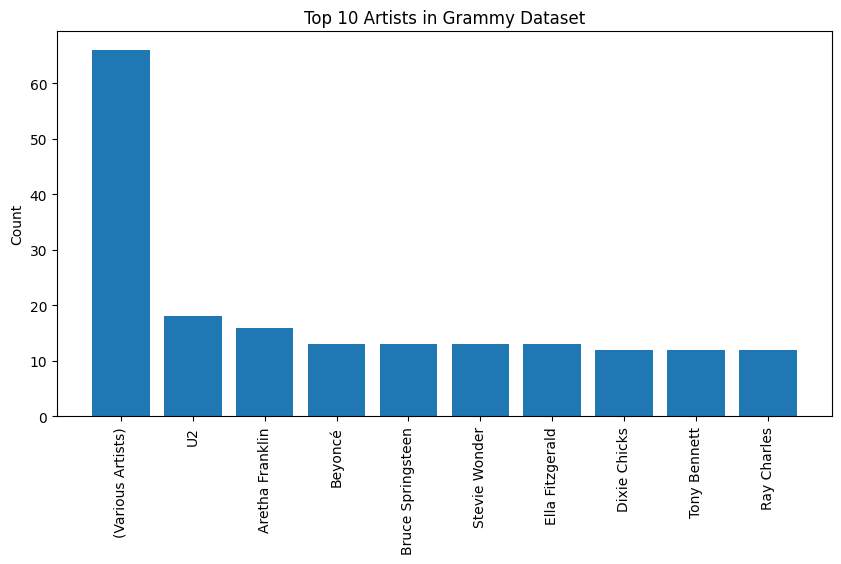

In [9]:
top_artists = grammys["artist"].dropna().value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_artists.index, top_artists.values)
plt.title("Top 10 Artists in Grammy Dataset")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

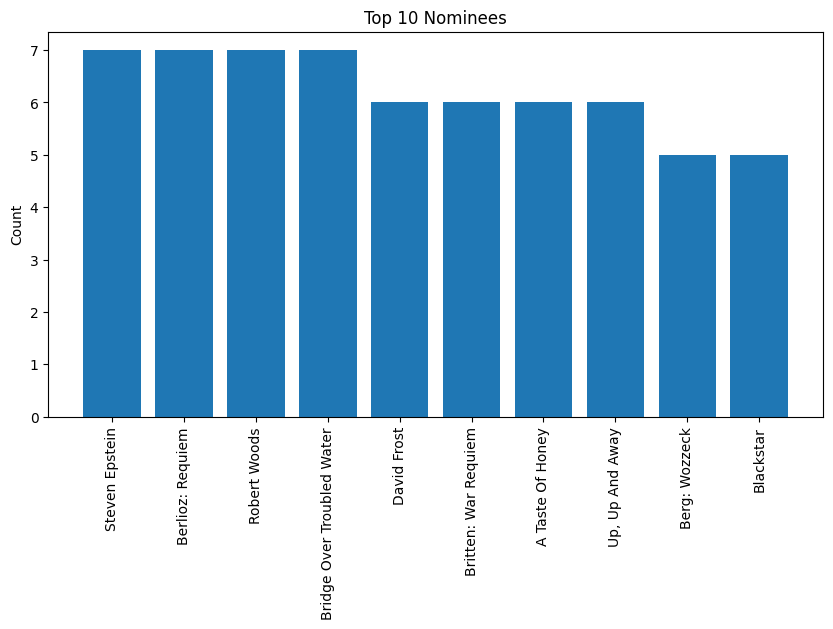

In [10]:
top_nominees = grammys["nominee"].dropna().value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_nominees.index, top_nominees.values)
plt.title("Top 10 Nominees")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()